# Identification of factors

In this notebook, we use the already trained DRVI model on the immune dataset to show different ways to identify a factor. In summary we can:

- Identify based on available annotation
- Identify using GSEA
- Identify using Language models
- Looking into the annotation databases

**We always advise examination by a biologist or looking into the published litereture for validation of the identified processes.**

## Intro

In this notrbook, we assume that the user has already trained DRVI on Immune data.

Please refer to [General training and interpretability pipeline](./general_pipeline.html) tutorial.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, next cell will install dependencies.

Please remove this part if your environment is already setup.

In [286]:
import sys

# if branch is stable, will install via pypi, else will install from source
branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    !pip install multigrate[tutorials]
elif IN_COLAB and branch != "stable":
    !pip install git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]

## Imports

In [287]:
import warnings
warnings.filterwarnings("ignore")

In [288]:
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [289]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.2


## Config

In [290]:
# Set this to false if you already trained your model and do not like to retrain.
overwrite = False
SEED = 1  # Set to None if you don't want to set seed

# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/")
io_dir.mkdir(parents=True, exist_ok=True)
io_dir

PosixPath('tmp_io/drvi_immune_128')

## Load Data

In [291]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad("/home/icb/clara.sanchez/workspace/data/drvi_immune_128/adata_preprocesses.h5ad")

## Load DRVI ouputs

In [292]:
model_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/drvi_model"
embed_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/embed.h5ad"
traverse_adata_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File /home/icb/clara.sanchez/workspace/data/drvi_immune_128/drvi_model/model.pt already downloaded        
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.2.                                  
INFO     DRVI: Loading model from DRVI version 0.2.1.                                                              
INFO     DRVI: Modifying model args from 0.2.1 to 0.2.2 (no user action required)                                  
INFO     DRVI: Removing prior_init_obs from model args.                                                            
INFO     DRVI: Done updating model args. Loading in 0.2.2.                                                         
INFO     DRVI: The model has been initialized                           

## Identify based on available annotations

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

In [293]:
annot_col = "final_annotation"

### Specific Imports

In [294]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

### Helper functions

In [295]:
def plot_packed_network(df, title_col='title', var_col='variable', val_col='value'):
    """
    Visualizes network with edge weights shown to 2 decimal places.
    """
    # Create Graph
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)
    
    # Custom Grid Layout Logic
    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components)**0.5)
    
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    
    # Draw Nodes & Edges
    nx.draw(G, pos, 
            with_labels=True, font_size=8, font_weight='bold', node_size=600,
            node_color=['#A0CBE2' if n in titles else '#FF9E9E' for n in G.nodes()],
            width=[d[val_col] * 4 for u, v, d in G.edges(data=True)], 
            edge_color='grey', alpha=0.6)
    
    # Draw Edge Labels (Weights rounded to 2 decimals)
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
            
    plt.axis('off')
    plt.show()

### Code

In [296]:
# Remove vanished dimensions
embed_nv = embed[:, embed.var['vanished'] == False].copy()
embed_nv

AnnData object with n_obs × n_vars = 32484 × 61
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [297]:
benchmark = DiscreteDisentanglementBenchmark(
    embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"],
)
benchmark.evaluate()
# You can optionally save benchmark object if you want.
# benchmark.save(filename)
# benchmark = DiscreteDisentanglementBenchmark.load(filename, embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs["final_annotation"], metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"])

In [298]:
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity[:5]  # only showing 5 rows

,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [299]:
filtering_threshold = 0.5

top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars='title', value_vars=smi_similarity.columns)
    .query("value >= @filtering_threshold")
    .reset_index(drop=True)
)
top_matches

,title,variable,value
0,DR 1,CD4+ T cells,0.535119
1,DR 41,CD10+ B cells,0.668039
2,DR 53,CD10+ B cells,0.773828
3,DR 31,CD10+ B cells,0.659314
4,DR 2,CD14+ Monocytes,0.761070
5,DR 3,CD14+ Monocytes,0.878655
6,DR 26,CD16+ Monocytes,0.661827
7,DR 9,CD16+ Monocytes,0.910748
8,DR 5,CD20+ B cells,0.758002
9,DR 7,CD20+ B cells,0.654006


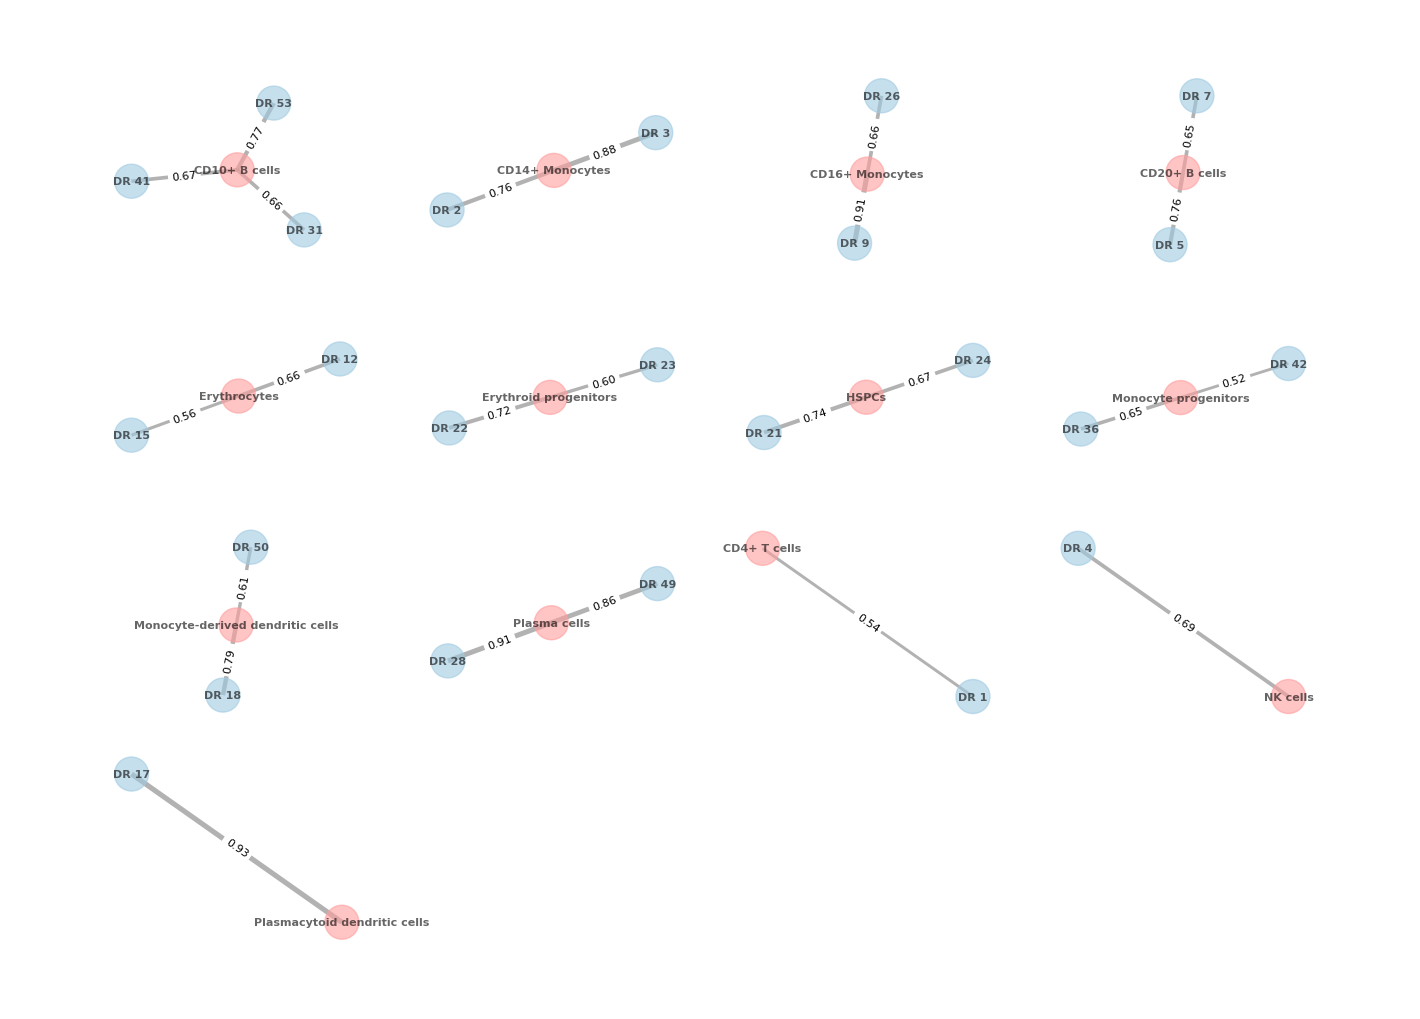

In [300]:
plot_packed_network(top_matches)

#### Heatmap

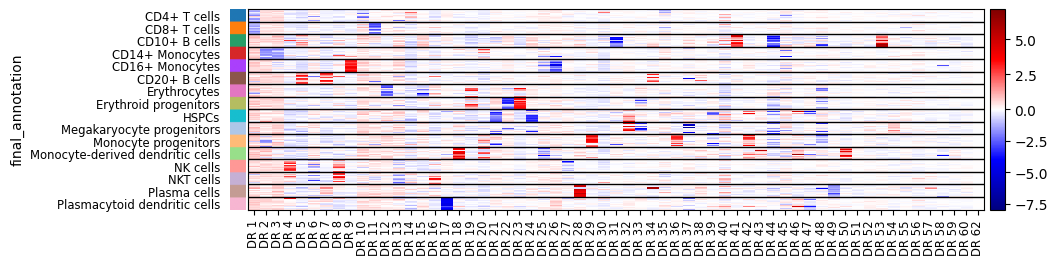

In [301]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title")

It is possible to sort dimensions based on the top relevance with respect to a categoricals variable

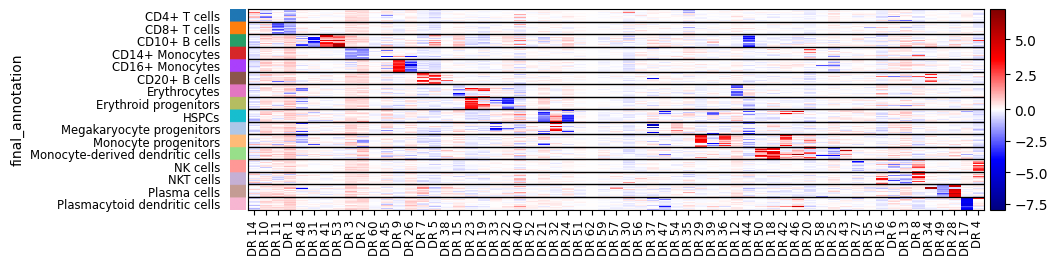

In [302]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title", sort_by_categorical=True)

## Identification of programs

Once we identify the top relevant genes, we can determine some programs through supervised external information, such as:
- existing annotations
- examination by biologists
- gene-set enrichment analysis (GSEA)
- scientific literature
- automated tools based on language models

**Please refer to this tutorial for some tools that we found useful for identification of programs**

It is worth mentioning that since such supervised information is not given to the model, the quality of the derived signatures is neither affected nor biased by it. Unidentified processes with high gene scores are promising candidates for further literature search, additional analysis, and even experimental design.

1. Input: 
-Gene list?
-Ranked list?
Expression Correlation with known Zelltype Markers
2. Reference Databases: 
-Classic Datatabases: Gene Ontology, Reactome, MSigDB? 
-Celltype specific Data (Cell Typist)
-LLMs: gsai?
3. Annotation Method:
-Over-representation
-Regressions based: How well does a set of genes explain a factor




# Exploration Roadmap: DRVI Factor Annotation Pipeline

This roadmap outlines the systematic evaluation of tools for annotating latent factors. The goal is to move from abstract dimensions to interpretable biological processes using the immune dataset as a pilot.

## General Roadmap Settings


### Shared Imports

In [303]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import celltypist
from celltypist import models

from gprofiler import GProfiler
import decoupler as dc
import blitzgsea as blitz
import gseapy as gp

### General Configurations and Settings

In [304]:
# Shared input behavior
GENE_CASE = "upper"  # "upper" or "none"
TOP_N = 300
FDR = 0.05

# CellTypist
CT_CORR_THRESHOLD = 0.40
CT_SPEC_THRESHOLD = 0.10

# GSEA tools (blitzgsea / gseapy)
GSEA_DB = "MSigDB_Hallmark_2020"
GSEAPY_MIN_SIZE = 10
GSEAPY_MAX_SIZE = 500
GSEAPY_PERMUTATIONS = 1000
BLITZGSEA_PROCESSES = 4

# g:Profiler
GP_ORGANISM = "hsapiens"
GP_SOURCES = None
GP_USER_THRESHOLD = 0.05
GP_ORDERED = False

# decoupler
DC_ORGANISM = "human"  # "human" or "mouse"
DC_GENESET = "msdib_hallmark"
DC_METHODS = ["ulm", "mlm", "zscore"]
DC_USE_CONSENSUS = True
DC_PRIMARY_METHOD = "ulm"
DC_TMIN = 5

# Input harmonization
USE_EMBED_FACTOR_NAMES = True
FACTOR_NAME_COL = "title"  # fallback to "original_dim_id" if missing




### Data Preparation
Works directly with existing session objects:
- `adata`, `embed`, `traverse_adata`
and prepares:
- `pos_df`, `neg_df` (genes x factors)
- aligned cell indices for `adata` and `embed_full`

In [305]:
#global background genes
adata_full = sc.read_h5ad("/home/icb/clara.sanchez/data/drvi_immune_128/immune_all.h5ad")
ALL_GENES = adata_full.var_names.astype(str).str.strip()

if GENE_CASE == "upper":
    ALL_GENES = ALL_GENES.str.upper()

ALL_GENES = pd.Index(ALL_GENES).drop_duplicates().tolist()
print(f"ALL_GENES: {len(ALL_GENES)} genes")



ALL_GENES: 12303 genes


In [306]:
# 1) Ensure embed_full exists
if "embed_full" not in globals() and "embed" in globals():
    embed_full = embed.copy()

# 2) Sync cells between adata and embedding
if "adata" in globals() and "embed_full" in globals():
    common_cells = adata.obs_names.intersection(embed_full.obs_names)
    adata = adata[common_cells].copy()
    embed_full = embed_full[common_cells].copy()
    print(f"Synced cells: {adata.n_obs}")

# 3) Ensure vanished info exists
if "vanished" not in embed_full.var.columns:
    drvi.utils.tl.set_latent_dimension_stats(model, embed_full, vanished_threshold=0.1)

# 4) Remove vanished dimensions
mask = ~embed_full.var["vanished"].astype(bool).values
embed = embed_full[:, mask].copy()
print(f"Factors after filtering: {embed.n_vars}")

# 5) Factor IDs for downstream analysis
factor_id_col = "title" if "title" in embed.var.columns else "original_dim_id"
factor_ids = embed.var[factor_id_col].astype(str).tolist()
drvi_factors = pd.DataFrame(embed.X, index=embed.obs_names, columns=factor_ids)

# 6) Create factor score matrices if needed
if "scores_df" not in globals() and not ("pos_df" in globals() and "neg_df" in globals()):
    if "traverse_adata" in globals():
        pos_df = traverse_adata.varm["combined_score_traverse_effect_pos"].copy()
        neg_df = traverse_adata.varm["combined_score_traverse_effect_neg"].copy()
    else:
        raise ValueError("Need `traverse_adata`, or provide `scores_df`, or provide both `pos_df` and `neg_df`.")

# 7) Keep score matrices aligned with filtered factors
if "pos_df" in globals() and "neg_df" in globals():
    if pos_df.shape[1] == len(mask) and neg_df.shape[1] == len(mask):
        pos_df = pos_df.iloc[:, mask].copy()
        neg_df = neg_df.iloc[:, mask].copy()
    if USE_EMBED_FACTOR_NAMES:
        pos_df.columns = factor_ids
        neg_df.columns = factor_ids

if "scores_df" in globals():
    if set(factor_ids).issubset(scores_df.columns):
        scores_df = scores_df.loc[:, factor_ids].copy()
    elif scores_df.shape[1] == len(mask):
        scores_df = scores_df.iloc[:, mask].copy()
        scores_df.columns = factor_ids

Synced cells: 32484
Factors after filtering: 61


### Shared Preprocessing

In [307]:
def standardize_scores_df(df: pd.DataFrame, gene_case: str = "upper") -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.astype(str).str.strip()
    if gene_case == "upper":
        out.index = out.index.str.upper()
    # Merge duplicated gene symbols after case normalization.
    out = out.groupby(out.index).max()
    return out


def build_inputs(df, top_n, gene_case="upper", all_genes=ALL_GENES):
    std = df.copy()
    std.index = std.index.astype(str).str.strip()
    if gene_case == "upper":
        std.index = std.index.str.upper()
    std = std.groupby(std.index).max()  # doppelte Gene zusammenfassen

    if all_genes is not None:
        idx = pd.Index(pd.Series(all_genes).astype(str)).drop_duplicates()
        std = std.reindex(idx).fillna(0.0)  # alle gemessenen Gene erzwingen

    ranked = {c: std[c].sort_values(ascending=False) for c in std.columns}
    top = {c: ranked[c].head(top_n).index.tolist() for c in std.columns}
    return std, ranked, top

In [308]:
if "scores_df" in globals():
    scores_std, ranked_lists, top_lists = build_inputs(scores_df, TOP_N, GENE_CASE, ALL_GENES)
    factor_ids = list(scores_std.columns)
elif "pos_df" in globals() and "neg_df" in globals():
    pos_std, pos_ranked, pos_top = build_inputs(pos_df, TOP_N, GENE_CASE, ALL_GENES)
    neg_std, neg_ranked, neg_top = build_inputs(neg_df, TOP_N, GENE_CASE, ALL_GENES)
    factor_ids = list(pos_std.columns)
else:
    raise ValueError("Need scores_df or pos_df+neg_df")


print(f"Factors: {len(factor_ids)}")

Factors: 61


In [309]:
# Check-Zelle: Anzahl Gene pro Tool-Input

print(f"ALL_GENES (background): {len(ALL_GENES)}")

# 1) blitzgsea / gseapy (ranked input)
if "ranked_inputs" in globals() and len(ranked_inputs) > 0:
    k = next(iter(ranked_inputs))
    print(f"[blitzgsea/gseapy] factors: {len(ranked_inputs)}")
    print(f"[blitzgsea/gseapy] genes in ranked list ({k}): {len(ranked_inputs[k])}")
else:
    print("[blitzgsea/gseapy] ranked_inputs fehlt")

# 2) g:Profiler (query + background)
if "pos_top" in globals() and len(pos_top) > 0:
    k = next(iter(pos_top))
    print(f"[g:Profiler] query genes (Top-N, pos) for {k}: {len(pos_top[k])}")
elif "top_lists" in globals() and len(top_lists) > 0:
    k = next(iter(top_lists))
    print(f"[g:Profiler] query genes (Top-N) for {k}: {len(top_lists[k])}")
else:
    print("[g:Profiler] top-list fehlt")
print(f"[g:Profiler] background genes: {len(ALL_GENES)}")

# 3) decoupler (matrix input)
if "pos_std" in globals():
    mat = pos_std.T.reindex(columns=ALL_GENES, fill_value=0.0)
    print(f"[decoupler] matrix shape (pos): {mat.shape}  # (factors, genes)")
elif "scores_std" in globals():
    mat = scores_std.T.reindex(columns=ALL_GENES, fill_value=0.0)
    print(f"[decoupler] matrix shape (all): {mat.shape}  # (factors, genes)")
else:
    print("[decoupler] scores matrix fehlt")


ALL_GENES (background): 12303
[blitzgsea/gseapy] factors: 122
[blitzgsea/gseapy] genes in ranked list (DR 36_pos): 12303
[g:Profiler] query genes (Top-N, pos) for DR 36: 300
[g:Profiler] background genes: 12303
[decoupler] matrix shape (pos): (61, 12303)  # (factors, genes)


### Ranked Inputs (blitzgsea and gseapy)

In [310]:
ranked_inputs = {}
if "pos_ranked" in globals() and "neg_ranked" in globals():
    for fac in factor_ids:
        ranked_inputs[f"{fac}_pos"] = pos_ranked[fac]
        ranked_inputs[f"{fac}_neg"] = neg_ranked[fac]
else:
    for fac in factor_ids:
        ranked_inputs[str(fac)] = ranked_lists[fac]

print(f"Ranked inputs: {len(ranked_inputs)}")

Ranked inputs: 122


## 1. Statistical Annotation & Similarity 

Goal: Map latent factors to known cell types using existing annotations and atlases.

Tools to Compare:
* CellTypist: Utilizing the Immune_All_Low.pkl or High models for automated labeling.
* GSEA: 
    * Azimuth 2023 or Azimuth_Cell_Types_2021 (Reference Marker lists from Human Biomolecular Atlas Program)
    * PanglaoDB_Augmented_2021 (Mouse and Human) --> clean markers lists
    * HuBMAP_ASCTplusB_augmented_2022 (Anatomical Structures, Cell Typs, Biomarkers) --> very well curated, strict anatomical hierarchy
    * Descartes_Cell_Types_and_Tissue_2021 (Human Cell Atlas) --> broad level annotation
    * Tabula Sapiens (one of the biggest Single Cell Atlases, 24 Organs)
    * ...




Key Metrics:
* Correlation
* Specificity


### 1.1 Cell Typist

* Input: normalized gene expression matrix of cells
* Reference: Pre-trained Logistic Regression models trained on millions of annotated cells in different tissues
* Algorithm: Linear Classification --> Calculates Decision Scores via linear combination of scaled expression and model coefficients, followed by a Maximum Score selection for identity.
* Output: 
    * Predicted Labels: Final call for each cell
    * Decision Matrix: Raw classification scores
    * Probability Matrix: Sigmoid-transformed scores (0 to 1)





#### CellTypist Model

In [311]:
#download celltypist model
print(models.models_description())
model_name = 'Immune_All_Low.pkl'
models.download_models(force_update=True, model=model_name)
ct_model = models.Model.load(model=model_name)

#load recommended model for immune cells
ct_model = models.Model.load(model=model_name)
print(ct_model.cell_types)

👉 Detailed model information can be found at `https://www.celltypist.org/models`
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json


                                      model  \
0                        Immune_All_Low.pkl   
1                       Immune_All_High.pkl   
2                    Adult_COVID19_PBMC.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                       Adult_Human_MTG.pkl   
5           Adult_Human_PancreaticIslet.pkl   
6          Adult_Human_PrefrontalCortex.pkl   
7                      Adult_Human_Skin.pkl   
8                  Adult_Human_Vascular.pkl   
9                       Adult_Mouse_Gut.pkl   
10            Adult_Mouse_OlfactoryBulb.pkl   
11                Adult_Pig_Hippocampus.pkl   
12      Adult_RhesusMacaque_Hippocampus.pkl   
13                Adult_cHSPCs_Illumina.pkl   
14                  Adult_cHSPCs_Ultima.pkl   
15                 Autopsy_COVID19_Lung.pkl   
16         COVID19_HumanChallenge_Blood.pkl   
17             COVID19_Immune_Landscape.pkl   
18                   Cells_Adult_Breast.pkl   
19                     Cells_Fetal_Lung.pkl   
20           

📚 Total models in list: 60
📂 Storing models in /home/icb/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


['Age-associated B cells' 'Alveolar macrophages' 'B cells'
 'CD16+ NK cells' 'CD16- NK cells' 'CD8a/a' 'CD8a/b(entry)' 'CMP'
 'CRTAM+ gamma-delta T cells' 'Classical monocytes' 'Cycling B cells'
 'Cycling DCs' 'Cycling NK cells' 'Cycling T cells'
 'Cycling gamma-delta T cells' 'Cycling monocytes' 'DC' 'DC precursor'
 'DC1' 'DC2' 'DC3' 'Double-negative thymocytes'
 'Double-positive thymocytes' 'ELP' 'ETP' 'Early MK' 'Early erythroid'
 'Early lymphoid/T lymphoid' 'Endothelial cells' 'Epithelial cells'
 'Erythrocytes' 'Erythrophagocytic macrophages' 'Fibroblasts'
 'Follicular B cells' 'Follicular helper T cells' 'GMP'
 'Germinal center B cells' 'Granulocytes' 'HSC/MPP' 'Hofbauer cells' 'ILC'
 'ILC precursor' 'ILC1' 'ILC2' 'ILC3' 'Intermediate macrophages'
 'Intestinal macrophages' 'Kidney-resident macrophages' 'Kupffer cells'
 'Large pre-B cells' 'Late erythroid' 'MAIT cells' 'MEMP' 'MNP'
 'Macrophages' 'Mast cells' 'Megakaryocyte precursor'
 'Megakaryocyte-erythroid-mast cell progenitor'

#### CellTypist Annotation


In [312]:
# Annotate cell types using CellTypist
predictions = celltypist.annotate(adata, model=model_name, majority_voting=True)

adata.obs['celltypist_labels'] = predictions.predicted_labels['predicted_labels']

adata.obs['celltypist_majority'] = predictions.predicted_labels['majority_voting']

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


#### Extract Probability Matrix

In [313]:
# The Probability Matrix contains sigmoid-transformed scores (0 to 1)
# This is the primary input for the factor correlation analysis
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names

# Quick check: How many cell types did the model find?
print(f"Modell knows {prob_matrix.shape[1]} different Immune cell types.")

Modell knows 98 different Immune cell types.


#### CellTypist Factor Mutual Information

In [314]:
annot_col = "final_annotation"

benchmark = DiscreteDisentanglementBenchmark(
    embed.X,
    dim_titles=embed.var["title"],
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"],
    aggregation_methods=["LMS"],
)
benchmark.evaluate()

smi = benchmark.get_results_details()["SMI-disc"]
smi_long = smi.reset_index().melt(id_vars="title", var_name="Label", value_name="SMI")
smi_long = smi_long.sort_values("SMI", ascending=False).reset_index(drop=True)


In [315]:
celltypist_summary = smi_long.rename(columns={"title": "Factor", "Label": "Top_CellType", "SMI": "Correlation"})
celltypist_summary["Specificity"] = np.nan

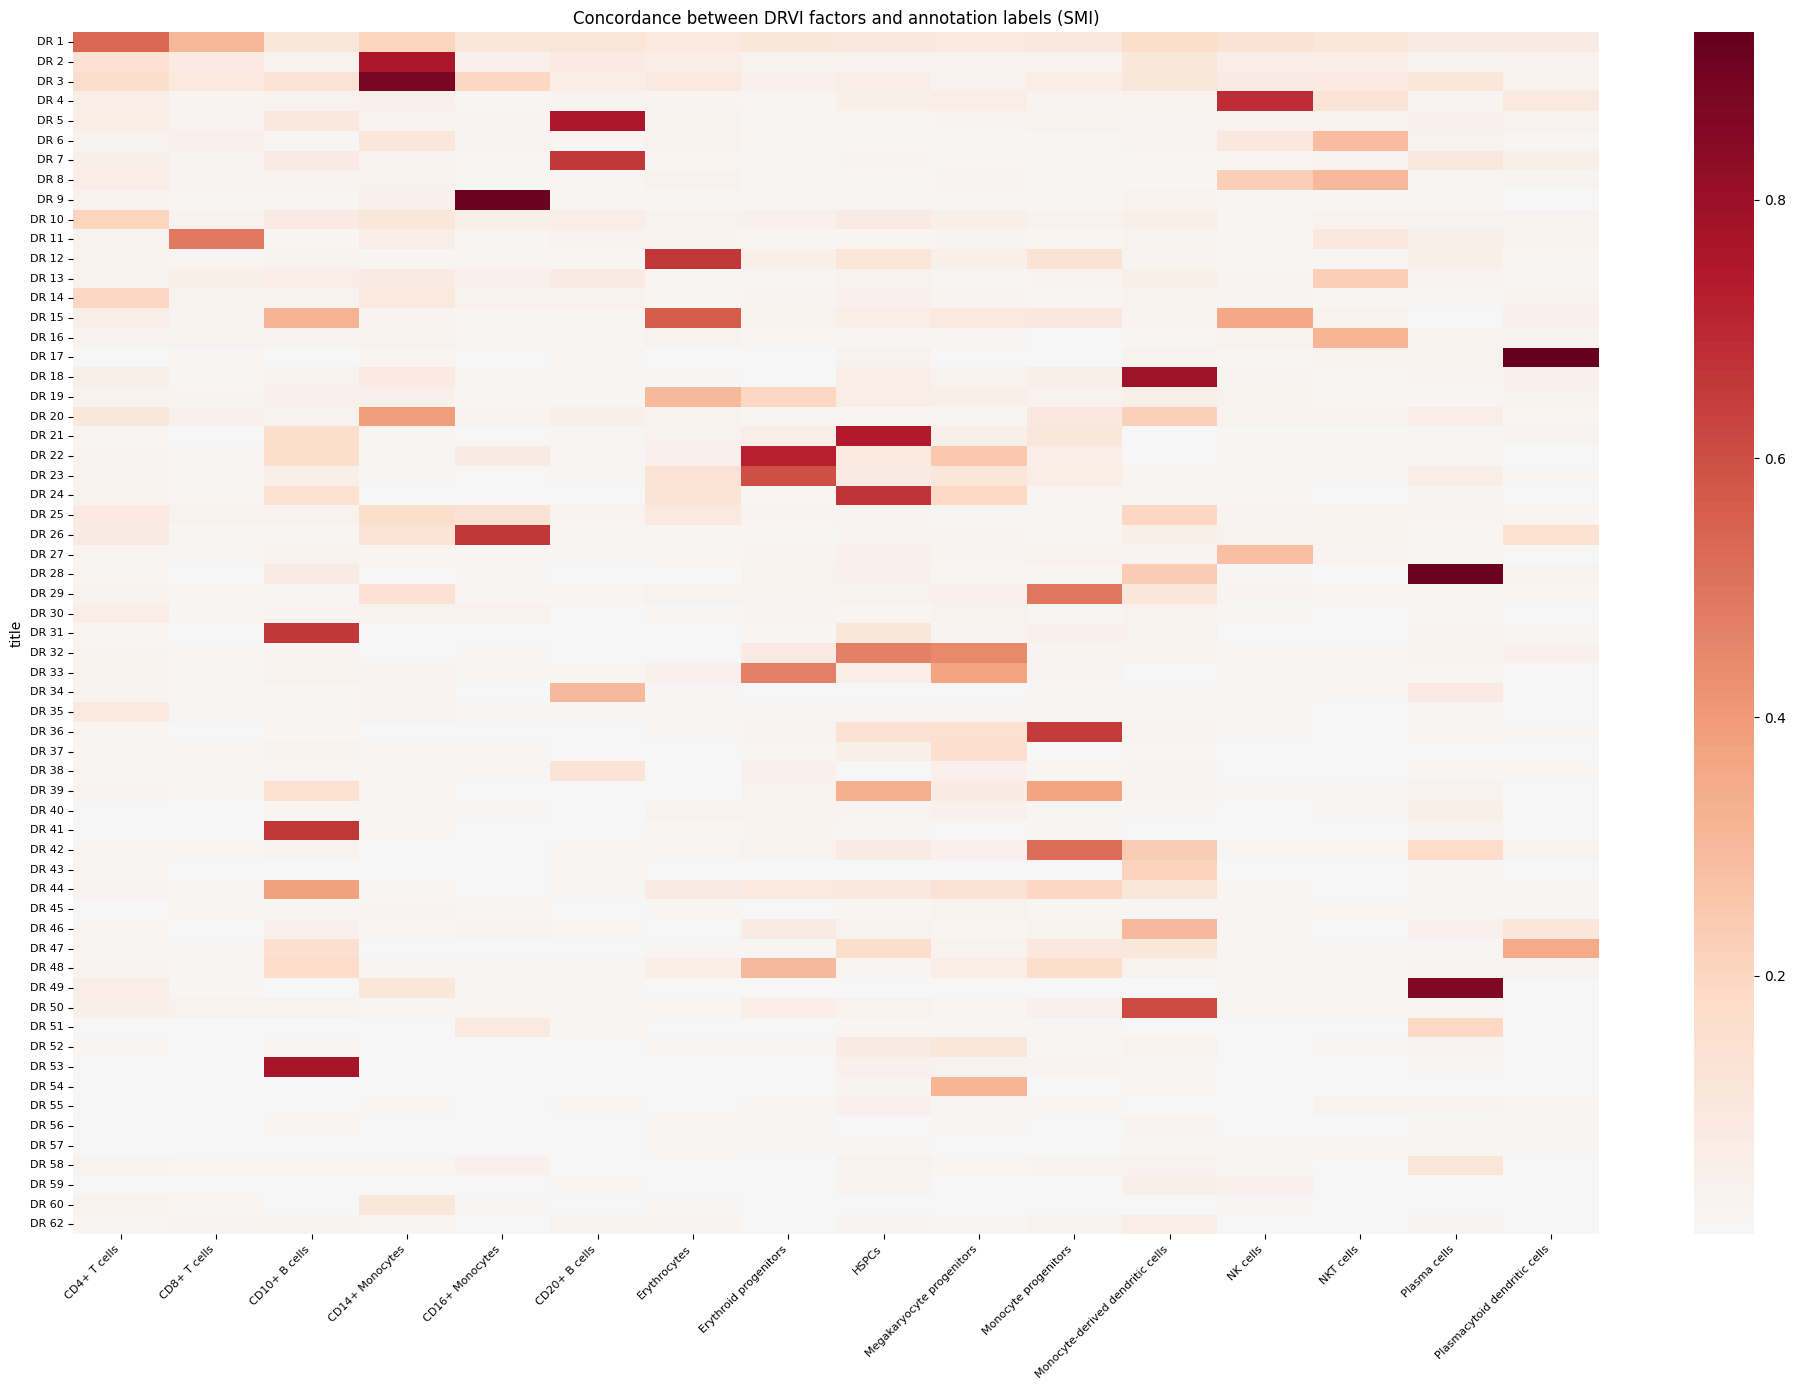

In [316]:
#Visualize with heatmap
smi_sorted = smi.copy()
smi_sorted = smi_sorted.loc[
    sorted(
        smi_sorted.index,
        key=lambda x: int(str(x).replace("DR", "").strip()) if str(x).replace("DR", "").strip().isdigit() else 10**9
    )
]

plt.figure(figsize=(20, 14))
ax = sns.heatmap(smi_sorted, cmap="RdBu_r", center=0)

ax.set_yticks(np.arange(smi_sorted.shape[0]) + 0.5)
ax.set_yticklabels(smi_sorted.index, rotation=0, fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.title("Concordance between DRVI factors and annotation labels (SMI)")
plt.tight_layout()
plt.show()

#### CellTypist Validation

In [317]:
factor_to_check = "DR 36"
adata.obs["factor_check"] = drvi_factors[factor_to_check].reindex(adata.obs_names)

UMAP

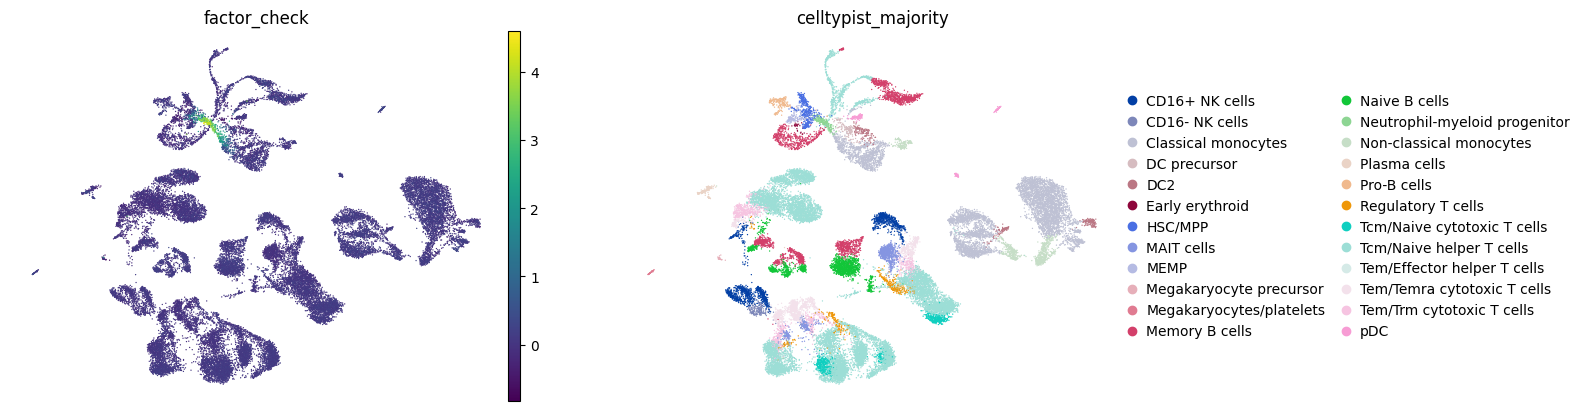

In [318]:
sc.pl.umap(
    adata,
    color=["factor_check", "celltypist_majority"],
    ncols=2,
    frameon=False,
    cmap="viridis",
)


Violin Plot

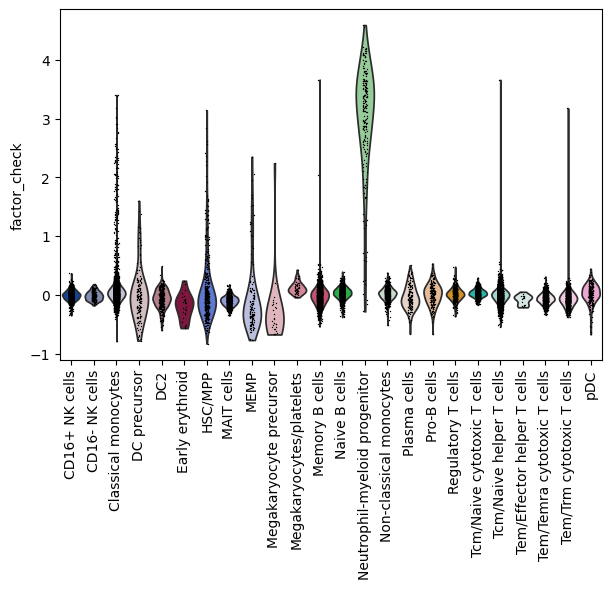

In [319]:
sc.pl.violin(
    adata,
    keys="factor_check",
    groupby="celltypist_majority",
    rotation=90
)

#### CellTypist Summary

In [320]:
# top and second-best label per factor (SMI)
top_1 = smi.idxmax(axis=1)
top_1_val = smi.max(axis=1)

tmp = smi.copy()
for i, c in enumerate(top_1):
    tmp.iloc[i, tmp.columns.get_loc(c)] = -1

# specificity = Abstand zwischen bestem und zweitbestem SMI
specificity = top_1_val - tmp.max(axis=1)

# Summary-Table (kompatibel zu Downstream)
celltypist_summary = pd.DataFrame({
    "Factor": smi.index,
    "Top_CellType": top_1.values,
    "SMI-value": top_1_val.values,   # hier: SMI-Score
    "Specificity": specificity.values,
})

celltypist_summary["Tool"] = "SMI"
celltypist_summary["Label_std"] = (
    celltypist_summary["Top_CellType"].astype(str)
    .str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
)
celltypist_summary["Significant"] = (
    (celltypist_summary["SMI-value"] >= CT_CORR_THRESHOLD)
    & (celltypist_summary["Specificity"] >= CT_SPEC_THRESHOLD)
)

display(celltypist_summary[celltypist_summary["Significant"]].head(20))

,Factor,Top_CellType,SMI-value,Specificity,Tool,Label_std,Significant
0,DR 36,Monocyte progenitors,0.652945,0.505441,SMI,monocyte_progenitors,True
1,DR 49,Plasma cells,0.859131,0.744023,SMI,plasma_cells,True
4,DR 2,CD14+ Monocytes,0.761070,0.620771,SMI,cd14_monocytes,True
5,DR 41,CD10+ B cells,0.668039,0.642334,SMI,cd10_b_cells,True
12,DR 29,Monocyte progenitors,0.495314,0.355487,SMI,monocyte_progenitors,True
13,DR 50,Monocyte-derived dendritic cells,0.609541,0.548011,SMI,monocyte_derived_dendritic_cells,True
14,DR 1,CD4+ T cells,0.535119,0.222924,SMI,cd4_t_cells,True
17,DR 5,CD20+ B cells,0.758002,0.660248,SMI,cd20_b_cells,True
23,DR 3,CD14+ Monocytes,0.878655,0.682051,SMI,cd14_monocytes,True
25,DR 11,CD8+ T cells,0.490036,0.388470,SMI,cd8_t_cells,True


## 2. Gene Set Enrichment Analysis (Functional Identity)

Goal: Identify biological processes (e.g., "Interferon Response", "Cell Cycle") for factors that do not map 1-to-1 to a cell type.

Tools to Compare:
* gProfiler (gprofiler-official): The benchmark used in the DRVI preprint
* Gseapy: Python implementation for local Enrichment analysis (Enrichr/MSigDB)
* Decoupler: A fast framework for footprint-based enrichment (e.g., PROXIMA)
* Blitzqseq

Key Metrics:

### 2.1 Blitzqseq

How it works:
* Input: Ranked gene list (list of ALL genes sorted by loadings for a specific factor)
* Reference: Database on Enrichr
    * Key Collections: 
        * e.g MgSigDB
            * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
            * C5 (GO): Highly specific Gene Ontology terms.
            * C2 (CP): Curated pathways from Reactome or KEGG.
        * Cellmarker/Azimuth
        * Reactome/KEGG
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Speed Optimization: BlitzGSEA uses a probability distribution approximation to estimate the null model. Instead of running thousands of slow permutations for every gene set, it uses mathematical shortcuts to calculate p-values almost instantly
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * p-value & FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Leading Edge Genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### BlitzGSEA Library

In [321]:
# MSigDB Hallmark is the gold standard for the first evaluation
signature_lib = blitz.enrichr.get_library("MSigDB_Hallmark_2020")

In [322]:
def _pick_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

##### GSEA

In [323]:
blitz_rows = []

for factor_dir, s in ranked_inputs.items():
    sig = s.dropna().reset_index()
    sig.columns = ["i", "v"]  # required by blitzgsea

    try:
        res = blitz.gsea(sig, signature_lib, processes=BLITZGSEA_PROCESSES)
        if res is None or res.empty:
            continue

        term = res["Term"] if "Term" in res.columns else pd.Series(res.index, index=res.index)
        fdr = res["fdr"] if "fdr" in res.columns else res["FDR"]
        nes = res["nes"] if "nes" in res.columns else res["NES"]

        blitz_rows.append(pd.DataFrame({
            "FactorDir": factor_dir,
            "Term": term.astype(str).values,
            "NES": pd.to_numeric(nes, errors="coerce").values,
            "FDR": pd.to_numeric(fdr, errors="coerce").values
        }))
    except Exception:
        pass

blitzgsea_summary = pd.concat(blitz_rows, ignore_index=True) if blitz_rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])



In [324]:
sig_blitz = blitzgsea_summary.query("FDR < @FDR")[["FactorDir","Term","FDR"]]
display(sig_blitz.sort_values("FDR").head(30))

,FactorDir,Term,FDR
950,DR 62_neg,TNF-alpha Signaling via NF-kB,0.018101
951,DR 62_neg,Interferon Gamma Response,0.018101
952,DR 62_neg,Oxidative Phosphorylation,0.018101
2850,DR 24_neg,Myc Targets V1,0.021576
2851,DR 24_neg,E2F Targets,0.021576
2852,DR 24_neg,Oxidative Phosphorylation,0.022544
3750,DR 56_neg,Myc Targets V1,0.023193
3751,DR 56_neg,TNF-alpha Signaling via NF-kB,0.024555
100,DR 49_pos,Myc Targets V1,0.026409
101,DR 49_pos,E2F Targets,0.026409


#### BlitzGSEA Summary

In [325]:
# Create a summary of significant GSEA results
annotated_blitz = blitzgsea_summary[blitzgsea_summary["FDR"] < FDR].copy() if not blitzgsea_summary.empty else pd.DataFrame()

#Calculate key performance indicators

# how many percent of latent factors got at least one significant annotation?
# We ignore the direction (_pos/_neg) when calculating coverage, as they represent the same underlying factor.
all_factor = blitzgsea_summary["FactorDir"].str.replace(r"_(pos|neg)$", "", regex=True)
hit_factor = annotated_blitz["FactorDir"].str.replace(r"_(pos|neg)$", "", regex=True)

n_total = all_factor.nunique()
n_hit = hit_factor.nunique()
coverage_blitz = 100 * n_hit / n_total if n_total else 0

print(f"BlitzGSEA factor coverage (FDR<{FDR}): {coverage_blitz:.2f}% ({n_hit}/{n_total})")

# how many unique terms were found? This indicates the diversity of biological processes captured by the factors.
print(f"Unique terms: {annotated_blitz['Term'].nunique() if not annotated_blitz.empty else 0}")

# Normalized Enrichment Score. A value above 2 is generally considered strong evidence of enrichment. The median NES gives a sense of the overall strength of the annotations.
print(f"Median NES: {annotated_blitz['NES'].median():.2f}" if not annotated_blitz.empty else "Median NES: n/a")

BlitzGSEA factor coverage (FDR<0.05): 42.62% (26/61)
Unique terms: 7
Median NES: -3.13


### 2.2 Gseapy (Preranking Module)

How it works:
* Input: 
    * Ranked gene list (list of ALL genes sorted by loadings for a specific factor) for Preranked Module [Important: Gene names have to be in capital letters]
    * Gene expression matrix and group annotation for classical module
* Reference: Database on Enrichr
    * Key Collections: 
        * e.g MgSigDB
            * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
            * C5 (GO): Highly specific Gene Ontology terms.
            * C2 (CP): Curated pathways from Reactome or KEGG.
        * Cellmarker/Azimuth
        * Reactome/KEGG
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Permutation-based Null Model: It randomly reassigns gene labels many times (default is 1000 iterations) to see how often a similar ES occurs by pure chance
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Lead_genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### Get Gene Library

In [326]:
gseapy_lib = blitz.enrichr.get_library(GSEA_DB)
print(f"gseapy DB: {GSEA_DB} | gene sets: {len(gseapy_lib)}")

gseapy DB: MSigDB_Hallmark_2020 | gene sets: 50


#### Run Gseapy Prerank Loop


In [327]:
gseapy_rows = []
for factor_dir, s in ranked_inputs.items():
    rnk = s.reset_index()
    rnk.columns = ["gene", "score"]
    try:
        pre_res = gp.prerank(
            rnk=rnk,
            gene_sets=gseapy_lib,
            min_size=GSEAPY_MIN_SIZE,
            max_size=GSEAPY_MAX_SIZE,
            permutation_num=GSEAPY_PERMUTATIONS,
            outdir=None,
            seed=0,
            verbose=False,
        )
        res = pre_res.res2d
        if res is None or res.empty:
            continue
        term_col = _pick_col(res, ["Term", "term"])
        nes_col = _pick_col(res, ["NES", "nes"])
        fdr_col = _pick_col(res, ["FDR q-val", "FDR", "fdr"])
        if term_col is None or nes_col is None or fdr_col is None:
            continue
        tmp = pd.DataFrame(
            {
                "FactorDir": factor_dir,
                "Term": res[term_col].astype(str).values,
                "NES": pd.to_numeric(res[nes_col], errors="coerce").values,
                "FDR": pd.to_numeric(res[fdr_col], errors="coerce").values,
            }
        )
        gseapy_rows.append(tmp)
    except Exception:
        continue

gseapy_summary = pd.concat(gseapy_rows, ignore_index=True) if gseapy_rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])



2026-02-18 11:55:28,037 [WARNING] Duplicated values found in preranked stats: 89.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-18 11:55:29,941 [WARNING] Duplicated values found in preranked stats: 91.86% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-18 11:55:31,479 [WARNING] Duplicated values found in preranked stats: 91.69% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-18 11:55:32,996 [WARNING] Duplicated values found in preranked stats: 89.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-18 11:55:34,505 [WARNING] Duplicated values found in preranked stats: 93.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-18 11:55:36,018 [WARNING] Duplicated values found in preranked stats: 88.24% of genes
The order of those genes w

In [328]:
sig_gseapy = gseapy_summary.query("FDR < @FDR")[["FactorDir","Term","FDR"]]
display(sig_gseapy.sort_values("FDR").head(30))

,FactorDir,Term,FDR
700,DR 59_pos,Oxidative Phosphorylation,0.000000
3000,DR 48_pos,E2F Targets,0.000000
3750,DR 56_neg,Oxidative Phosphorylation,0.000000
5300,DR 22_pos,G2-M Checkpoint,0.000000
5400,DR 17_pos,Myc Targets V1,0.000000
3751,DR 56_neg,Myc Targets V1,0.001006
3200,DR 12_pos,Spermatogenesis,0.004107
4200,DR 23_pos,Pancreas Beta Cells,0.017819
4800,DR 21_pos,Oxidative Phosphorylation,0.020280
2251,DR 45_neg,Unfolded Protein Response,0.020602


#### Gseapy Summary


In [329]:
annotated_gseapy = (
    gseapy_summary[gseapy_summary["FDR"] < FDR].copy()
    if ("gseapy_summary" in globals() and not gseapy_summary.empty and "FDR" in gseapy_summary.columns)
    else pd.DataFrame(columns=["FactorDir"])
)

all_factor = (
    gseapy_summary["FactorDir"].astype(str).str.replace(r"_(pos|neg)$", "", regex=True)
    if ("gseapy_summary" in globals() and "FactorDir" in gseapy_summary.columns)
    else pd.Series([], dtype=str)
)

hit_factor = (
    annotated_gseapy["FactorDir"].astype(str).str.replace(r"_(pos|neg)$", "", regex=True)
    if "FactorDir" in annotated_gseapy.columns
    else pd.Series([], dtype=str)
)

n_total = all_factor.nunique()
n_hit = hit_factor.nunique()
coverage_gseapy = 100 * n_hit / n_total if n_total else 0.0
print(f"GSEApy coverage: {coverage_gseapy:.2f}% ({n_hit}/{n_total})")

#Unique terms
print(f"Unique terms: {annotated_gseapy['Term'].nunique() if not annotated_gseapy.empty else 0}")
print(f"Median NES: {annotated_gseapy['NES'].median():.2f}" if not annotated_gseapy.empty else "Median NES: n/a")


GSEApy coverage: 18.03% (11/61)
Unique terms: 8
Median NES: 1.05


### 2.3 gprofiler

How it works:
* Input: 
    * Ordered gene list: List of genes sorted by loadings (only top list as query)
    * Background Gene Set: List of all genes that were measured in experiment
    * Identifiers: many formats can be converted by g:Convert
* Reference: broad integration of many sources (g:GOSt)
    * Gene Ontology
    * Biological Pathways: KEGG, Reactome,..
    * Regulatory Motifs: Transfaci, MIRNA
    * Protein data bases
    * ...
* Algorithm: Over Representation Analysis
    * Hypergeometric test: calculates probability that overlap is only by pure chance
    * Ordered Query: It calculates a p-value at each step and identifies the specific "cutoff" point where the enrichment significance is at its maximum (the lowest p-value)
    * g:SCS (Significance Threshold): own algorithm to correct for multiple testing, optimized for hierarchical structure of GO-terms (tighter than FDR)
* Output: 
    * p-value
    * Intersection size: how many of your genes are found in pathway
    * Manhattan plot: interactive visualization that groups results by data base

In [330]:
gp = GProfiler(return_dataframe=True)

#### Helper function

In [331]:
def run_gprofiler_for_gene_list(genes, factor, direction):
    genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
    if not genes:
        return pd.DataFrame()

    kwargs = dict(
        organism=GP_ORGANISM,
        query=genes,
        user_threshold=GP_USER_THRESHOLD,
        ordered=GP_ORDERED,
        background=ALL_GENES,
    )
    if GP_SOURCES:
        kwargs["sources"] = GP_SOURCES

    res = gp.profile(**kwargs)
    if res is None or res.empty:
        return pd.DataFrame()

    res = res.copy()
    res["factor"] = factor
    res["direction"] = direction
    return res

#### Run

In [332]:
gprofiler_parts = []

if "pos_top" in globals() and "neg_top" in globals():
    for fac in factor_ids:
        gprofiler_parts.append(run_gprofiler_for_gene_list(pos_top[fac], fac, "pos"))
        gprofiler_parts.append(run_gprofiler_for_gene_list(neg_top[fac], fac, "neg"))
else:
    for fac in factor_ids:
        gprofiler_parts.append(run_gprofiler_for_gene_list(top_lists[fac], fac, "all"))

gprofiler_valid = [x for x in gprofiler_parts if not x.empty]
gprofiler_res = pd.concat(gprofiler_valid, ignore_index=True) if gprofiler_valid else pd.DataFrame()


In [333]:
sig_gprof = gprofiler_res.query("p_value < @FDR").copy()
sig_gprof["Term"] = sig_gprof["name"] if "name" in sig_gprof else sig_gprof["native"]
display(sig_gprof[["factor","Term","p_value"]].sort_values("p_value").head(30))


,factor,Term,p_value
6934,DR 50,immune response,1.571074e-46
16242,DR 54,immune response,4.356972e-46
16243,DR 54,immune system process,5.213047e-45
11344,DR 25,defense response,1.168253e-44
13448,DR 45,immune response,6.287994e-44
6935,DR 50,immune system process,1.053295e-43
11345,DR 25,immune response,2.776989e-43
24281,DR 53,immune response,8.460977e-42
11346,DR 25,Immune System,2.829212e-41
30846,DR 26,defense response,4.587679e-41


#### Summary

In [334]:
g_sig = gprofiler_res[gprofiler_res["p_value"] < FDR].copy() if not gprofiler_res.empty else pd.DataFrame()

# coverage 
all_factor = gprofiler_res["factor"].astype(str).str.replace(r"_(pos|neg)$", "", regex=True) if not gprofiler_res.empty else pd.Series(dtype=str)
hit_factor = g_sig["factor"].astype(str).str.replace(r"_(pos|neg)$", "", regex=True) if not g_sig.empty else pd.Series(dtype=str)

g_n_total = all_factor.nunique()
g_n_hit = hit_factor.nunique()
g_coverage = 100 * g_n_hit / g_n_total if g_n_total else 0

# unique terms
g_terms_col = "name" if "name" in g_sig.columns else "native"
g_n_terms = g_sig[g_terms_col].nunique() if not g_sig.empty else 0

# median effect size
g_median_effect = (-np.log10(g_sig["p_value"])).median() if not g_sig.empty else float("nan")

print(f"g:Profiler coverage (FDR<{FDR}): {g_coverage:.2f}% ({g_n_hit}/{g_n_total})")
print(f"Unique terms: {g_n_terms}")
print(f"Median -log10(p): {g_median_effect:.2f}")




g:Profiler coverage (FDR<0.05): 100.00% (61/61)
Unique terms: 2177
Median -log10(p): 3.62


### 2.4 Decoupler

How it works:
* Input: 
    * Matrix: expects gene sets in long format (source, target, weight)
* Reference: Omnipath which is a metadata base that integrates many different data bases
    * enables access too almost every available data abse using dc.get_resource()
* Algorithm: Ensemble platform --> run different methods on same data set
    * Multivariate Linear Model: very fast and often more precise than GSEA for loadings
    * Univariate Linear Model: similar to statistical regression
    * AUCell: measure activity of gene sets in individual cells/factors\
    * ORA & GSEA
* Output: Activity Scores --> how active a process is in a factor
    * Concencus Score --> can combine different methods for more robust results

#### Imports

In [335]:
import decoupler as dc

#### Load gene set

In [336]:
gs = str(DC_GENESET).strip().lower()

if gs in ["hallmark", "msigdb_hallmark", "msigdb-hallmark", "msdib_hallmark"]:
    net = dc.op.hallmark(organism=DC_ORGANISM)

elif gs == "progeny":
    net = dc.op.progeny(organism=DC_ORGANISM)

elif gs == "dorothea":
    net = dc.op.dorothea(organism=DC_ORGANISM, levels=["A", "B", "C"])

elif gs == "collectri":
    net = dc.op.collectri(organism=DC_ORGANISM)

else:
    # any OmniPath resource name, e.g. "PanglaoDB"
    net = dc.op.resource(name=DC_GENESET, organism=DC_ORGANISM)

# Keep only required columns for decouple()
cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)

#### Runner

In [337]:
def run_decouple(df_factors_by_genes: pd.DataFrame, direction: str) -> pd.DataFrame:
    mat = df_factors_by_genes.copy()

    # Gene müssen in den SPALTEN sein -> deshalb columns reindexen
    mat.columns = mat.columns.astype(str).str.strip()
    if GENE_CASE == "upper":
        mat.columns = mat.columns.str.upper()

    mat = mat.reindex(columns=ALL_GENES, fill_value=0.0)

    net_use = net.copy()
    net_use["target"] = net_use["target"].astype(str).str.strip()
    if GENE_CASE == "upper":
        net_use["target"] = net_use["target"].str.upper()

    res = dc.mt.decouple(
        data=mat,
        net=net_use,
        methods=DC_METHODS,
        cons=False,
        tmin=DC_TMIN,
        verbose=False,
    )

    if DC_USE_CONSENSUS and len(DC_METHODS) > 1:
        _, pvals = dc.mt.consensus(res)
    else:
        key = f"pvals_{DC_PRIMARY_METHOD}"
        if key not in res:
            return pd.DataFrame(columns=["factor", "term", "p_value", "direction"])
        pvals = res[key]

    out = pvals.stack().rename("p_value").reset_index()
    out.columns = ["factor", "term", "p_value"]
    out["direction"] = direction
    return out


#### Run

In [338]:
if "pos_std" in globals() and "neg_std" in globals():
    dec_pos = run_decouple(pos_std.T, "pos")
    dec_neg = run_decouple(neg_std.T, "neg")
    decoupler_res = pd.concat([dec_pos, dec_neg], ignore_index=True)
else:
    decoupler_res = run_decouple(scores_std.T, "all")


print("rows:", len(decoupler_res))
print("unique factors:", decoupler_res["factor"].astype(str).str.replace(r"_(pos|neg)$","", regex=True).nunique())
print("unique terms:", decoupler_res["term"].nunique())
print("significant rows:", (decoupler_res["p_value"] < FDR).sum())

rows: 5856
unique factors: 61
unique terms: 48
significant rows: 13


In [339]:
sig_dec = decoupler_res.query("p_value < @FDR")[["factor","term","p_value"]]
display(sig_dec.sort_values("p_value").head(30))


,factor,term,p_value
1050,DR 40,TNFA_SIGNALING_VIA_NFKB,0.001017
4916,DR 15,HEME_METABOLISM,0.001095
4484,DR 12,HEME_METABOLISM,0.001211
4986,DR 23,TNFA_SIGNALING_VIA_NFKB,0.003343
4362,DR 60,TNFA_SIGNALING_VIA_NFKB,0.009404
5100,DR 44,E2F_TARGETS,0.011344
721,DR 16,ALLOGRAFT_REJECTION,0.013800
5008,DR 53,FATTY_ACID_METABOLISM,0.015725
1172,DR 19,HEME_METABOLISM,0.015918
138,DR 33,TNFA_SIGNALING_VIA_NFKB,0.019737


#### Summary

In [340]:
d_sig = decoupler_res[decoupler_res["p_value"] < FDR].copy() if not decoupler_res.empty else pd.DataFrame()

# coverage 
all_factor = decoupler_res["factor"].astype(str).str.replace(r"_(pos|neg)$", "", regex=True) if not decoupler_res.empty else pd.Series(dtype=str)
hit_factor = d_sig["factor"].astype(str).str.replace(r"_(pos|neg)$", "", regex=True) if not d_sig.empty else pd.Series(dtype=str)

d_n_total = all_factor.nunique()
d_n_hit = hit_factor.nunique()
d_coverage = 100 * d_n_hit / d_n_total if d_n_total else 0

#Unique terms
d_n_terms = d_sig["term"].nunique() if not d_sig.empty else 0

#median effect size
d_median_effect = (-np.log10(d_sig["p_value"])).median() if not d_sig.empty else float("nan")

print(f"decoupler coverage (FDR<{FDR}): {d_coverage:.2f}% ({d_n_hit}/{d_n_total})")
print(f"Unique terms: {d_n_terms}")
print(f"Median -log10(p): {d_median_effect:.2f}")

decoupler coverage (FDR<0.05): 19.67% (12/61)
Unique terms: 5
Median -log10(p): 1.86


### Summary of results across tools

#### Top-hit Table (Alignment Check)

In [341]:
import re

def base_factor(x):
    x = str(x)
    x = re.sub(r'(_pos|_neg)$', '', x)
    x = re.sub(r'([+-])$', '', x)
    return x

def top_gseapy_sig(df):
    if df is None or df.empty: return pd.DataFrame(columns=["factor","gseapy"])
    x = df[df["FDR"] < FDR].copy()
    if x.empty: return pd.DataFrame(columns=["factor","gseapy"])
    x["factor"] = x["FactorDir"].map(base_factor)
    x = x.sort_values(["FDR","NES"], ascending=[True, False]).groupby("factor", as_index=False).head(1)
    x["gseapy"] = x["Term"].astype(str) + " | NES=" + x["NES"].round(2).astype(str)
    return x[["factor","gseapy"]]

def top_blitz_sig(df):
    if df is None or df.empty: return pd.DataFrame(columns=["factor","blitzgsea"])
    x = df[df["FDR"] < FDR].copy()
    if x.empty: return pd.DataFrame(columns=["factor","blitzgsea"])
    x["factor"] = x["FactorDir"].map(base_factor)
    x = x.sort_values(["FDR","NES"], ascending=[True, False]).groupby("factor", as_index=False).head(1)
    x["blitzgsea"] = x["Term"].astype(str) + " | NES=" + x["NES"].round(2).astype(str)
    return x[["factor","blitzgsea"]]

def top_gprof_sig(df):
    if df is None or df.empty: return pd.DataFrame(columns=["factor","gprofiler"])
    x = df[df["p_value"] < FDR].copy()
    if x.empty: return pd.DataFrame(columns=["factor","gprofiler"])
    term_col = "name" if "name" in x.columns else "native"
    x["factor"] = x["factor"].map(base_factor)
    x = x.sort_values("p_value").groupby("factor", as_index=False).head(1)
    x["gprofiler"] = x[term_col].astype(str) + " | p=" + x["p_value"].map(lambda v: f"{v:.2e}")
    return x[["factor","gprofiler"]]

def top_dec_sig(df):
    if df is None or df.empty: return pd.DataFrame(columns=["factor","decoupler"])
    x = df[df["p_value"] < FDR].copy()
    if x.empty: return pd.DataFrame(columns=["factor","decoupler"])
    x["factor"] = x["factor"].map(base_factor)
    x = x.sort_values("p_value").groupby("factor", as_index=False).head(1)
    x["decoupler"] = x["term"].astype(str) + " | p=" + x["p_value"].map(lambda v: f"{v:.2e}")
    return x[["factor","decoupler"]]

def top_celltypist_sig(df):
    if df is None or df.empty: return pd.DataFrame(columns=["factor","celltypist"])
    x = df.copy()
    fac_col = "Factor" if "Factor" in x.columns else ("factor" if "factor" in x.columns else None)
    ct_col = "Top_CellType" if "Top_CellType" in x.columns else ("CellType" if "CellType" in x.columns else None)
    corr_col = "Correlation" if "Correlation" in x.columns else None
    if fac_col is None or ct_col is None or corr_col is None:
        return pd.DataFrame(columns=["factor","celltypist"])

    # nutzt deine vorhandenen thresholds
    x = x[(x[corr_col] >= CT_CORR_THRESHOLD) & (x["Specificity"] >= CT_SPEC_THRESHOLD)].copy()
    if x.empty: return pd.DataFrame(columns=["factor","celltypist"])

    x["factor"] = x[fac_col].map(base_factor)
    x = x.sort_values(corr_col, ascending=False).groupby("factor", as_index=False).head(1)
    x["celltypist"] = x[ct_col].astype(str) + " | corr=" + x[corr_col].round(2).astype(str)
    return x[["factor","celltypist"]]

m = top_gseapy_sig(gseapy_summary)
m = m.merge(top_blitz_sig(blitzgsea_summary), on="factor", how="outer")
m = m.merge(top_gprof_sig(gprofiler_res), on="factor", how="outer")
m = m.merge(top_dec_sig(decoupler_res), on="factor", how="outer")
m = m.merge(top_celltypist_sig(celltypist_summary), on="factor", how="outer")

eval_matrix_sig = m.sort_values("factor").set_index("factor")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

display(eval_matrix_sig.dropna(how="all"))


,gseapy,blitzgsea,gprofiler,decoupler,celltypist
factor,,,,,
DR 1,NaN,Oxidative Phosphorylation | NES=-3.2,T cell activation | p=2.39e-24,NaN,NaN
DR 10,NaN,Oxidative Phosphorylation | NES=-3.12,T cell activation | p=1.39e-30,NaN,NaN
DR 11,NaN,Oxidative Phosphorylation | NES=-3.15,immune system process | p=3.33e-29,NaN,NaN
DR 12,Spermatogenesis | NES=1.05,NaN,immune system process | p=3.13e-24,HEME_METABOLISM | p=1.21e-03,NaN
DR 13,NaN,Oxidative Phosphorylation | NES=-3.2,immune response | p=2.17e-32,ALLOGRAFT_REJECTION | p=4.61e-02,NaN
DR 14,NaN,Oxidative Phosphorylation | NES=-3.2,immune response | p=6.98e-27,NaN,NaN
DR 15,NaN,NaN,immune system process | p=4.35e-18,HEME_METABOLISM | p=1.09e-03,NaN
DR 16,NaN,Oxidative Phosphorylation | NES=-3.13,immune response | p=8.41e-39,ALLOGRAFT_REJECTION | p=1.38e-02,NaN
DR 17,Myc Targets V1 | NES=1.04,NaN,immune system process | p=1.86e-33,NaN,NaN


#### Consistency Heatmap (Rank Correlation)

In [342]:
TOP_K = 20
FACTOR_FILTER = None   # z.B. "DR 36" oder None für alle Faktoren

def norm_term(s):
    return (pd.Series(s).astype(str).str.lower()
            .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))

def strip_factor(x):
    return (pd.Series(x).astype(str)
            .str.replace(r"_(pos|neg)$", "", regex=True)
            .str.replace(r"([+-])$", "", regex=True))

parts = []

# gseapy
if "gseapy_summary" in globals() and not gseapy_summary.empty:
    x = gseapy_summary.copy()
    x["factor"] = strip_factor(x["FactorDir"])
    x["term"] = norm_term(x["Term"])
    x["score"] = -np.log10(pd.to_numeric(x["FDR"], errors="coerce"))
    x["tool"] = "gseapy"
    parts.append(x[["tool","factor","term","score"]])

# blitzgsea
if "blitzgsea_summary" in globals() and not blitzgsea_summary.empty:
    x = blitzgsea_summary.copy()
    x["factor"] = strip_factor(x["FactorDir"])
    x["term"] = norm_term(x["Term"])
    x["score"] = -np.log10(pd.to_numeric(x["FDR"], errors="coerce"))
    x["tool"] = "blitzgsea"
    parts.append(x[["tool","factor","term","score"]])

# g:Profiler
if "gprofiler_res" in globals() and not gprofiler_res.empty:
    x = gprofiler_res.copy()
    term_col = "name" if "name" in x.columns else "native"
    x["factor"] = strip_factor(x["factor"])
    x["term"] = norm_term(x[term_col])
    x["score"] = -np.log10(pd.to_numeric(x["p_value"], errors="coerce"))
    x["tool"] = "gprofiler"
    parts.append(x[["tool","factor","term","score"]])

# decoupler
if "decoupler_res" in globals() and not decoupler_res.empty:
    x = decoupler_res.copy()
    x["factor"] = strip_factor(x["factor"])
    x["term"] = norm_term(x["term"])
    x["score"] = -np.log10(pd.to_numeric(x["p_value"], errors="coerce"))
    x["tool"] = "decoupler"
    parts.append(x[["tool","factor","term","score"]])

rank_df = pd.concat(parts, ignore_index=True).dropna(subset=["score"])
if FACTOR_FILTER is not None:
    rank_df = rank_df[rank_df["factor"] == FACTOR_FILTER].copy()

# pro Tool+Term den besten Score behalten
rank_df = rank_df.groupby(["tool","term"], as_index=False)["score"].max()
rank_df["rank"] = rank_df.groupby("tool")["score"].rank(ascending=False, method="dense")
rank_df.head()



,tool,term,score,rank
0,blitzgsea,adipogenesis,0.646713,26.0
1,blitzgsea,allograft_rejection,1.243052,6.0
2,blitzgsea,androgen_response,0.687539,22.0
3,blitzgsea,angiogenesis,0.638880,28.0
4,blitzgsea,apical_junction,0.697208,19.0


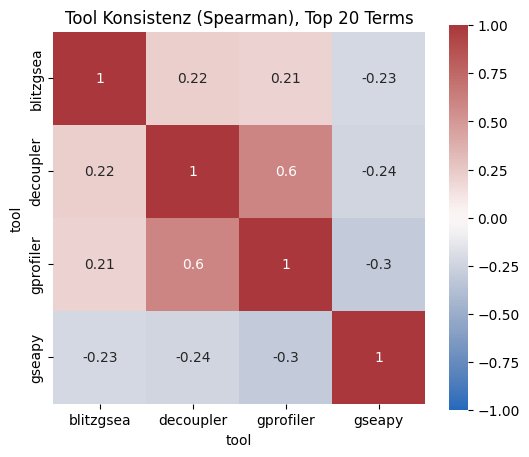

In [343]:
top_terms = rank_df[rank_df["rank"] <= TOP_K]["term"].unique()
r = rank_df[rank_df["term"].isin(top_terms)].copy()

rank_mat = r.pivot(index="term", columns="tool", values="rank")
corr = rank_mat.corr(method="spearman", min_periods=3)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="vlag", square=True)
plt.title(f"Tool Konsistenz (Spearman), Top {TOP_K} Terms" + (f" | {FACTOR_FILTER}" if FACTOR_FILTER else ""))
plt.show()

#### Leading-Edge-Gen-Overlap

#### Computing Time

### 3. Language Model Based Identification (Advanced Annotation)

Goal: Automate "narrative" annotation and validation using LLMs.

Tools to Compare:
* gsai (Gene Set AI): Specialized LLM tool for gene list interpretation.
* Direct LLM Prompting: Using GPT-4/Claude via API to summarize factor-defining genes.
* OpenScholar: For literature-backed validation of the proposed factor names.

Key Metrics:

### 4. Final Integration & Verification

Goal: Create the final notebook structure to guide the user.

Implementation:
* Unified API: A single function to call all three categories and present a summary table.
* Verify Cells: Visual sanity checks (UMAPs + Dotplots) to verify that a factor's activity matches the assigned name.
* Filtering: Automating the exclusion of "Vanished Factors" (max absolute value < 1) to reduce noise.